In [1]:
import os

print(os.getcwd())

c:\Users\Dell\OneDrive\Desktop\Fintech_Data_Analytics\Notebooks


In [2]:
import os

print(os.listdir(".."))

['.git', 'dashboard', 'Data', 'data_dictionary.md', 'data_ingestion.py', 'live_nav_fetch.py', 'Notebooks', 'queries.sql', 'README.md', 'reports', 'requirements.txt', 'Scripts', 'sql', 'Untitled.ipynb', 'venv']


In [3]:
import pandas as pd

nav = pd.read_csv("../Data/processed/nav_history_clean.csv")

print(nav.head())
print(nav.columns)

   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692
Index(['amfi_code', 'date', 'nav'], dtype='str')


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load NAV data
nav = pd.read_csv("../Data/processed/nav_history_clean.csv")

# Convert date column to datetime
nav["date"] = pd.to_datetime(nav["date"])

# Sort data properly
nav = nav.sort_values(["amfi_code", "date"])

# Reset index
nav = nav.reset_index(drop=True)

# Basic checks
print("Shape:", nav.shape)
print("\nColumns:")
print(nav.columns)

print("\nMissing Values:")
print(nav.isnull().sum())

print("\nFirst 5 Rows:")
print(nav.head())

Shape: (46000, 3)

Columns:
Index(['amfi_code', 'date', 'nav'], dtype='str')

Missing Values:
amfi_code    0
date         0
nav          0
dtype: int64

First 5 Rows:
   amfi_code       date       nav
0     100016 2022-01-03  520.4608
1     100016 2022-01-04  515.0971
2     100016 2022-01-05  521.7239
3     100016 2022-01-06  515.7880
4     100016 2022-01-07  515.1639


In [5]:
# Daily Return = NAV_t / NAV_t-1 - 1

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

print(nav.head(10))

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
5     100016 2022-01-10  510.7136     -0.008639
6     100016 2022-01-11  513.5542      0.005562
7     100016 2022-01-12  512.3195     -0.002404
8     100016 2022-01-13  510.2445     -0.004050
9     100016 2022-01-14  514.3636      0.008073


In [6]:
nav.to_csv(
    "../Data/processed/nav_with_returns.csv",
    index=False
)

print("Saved successfully!")

Saved successfully!


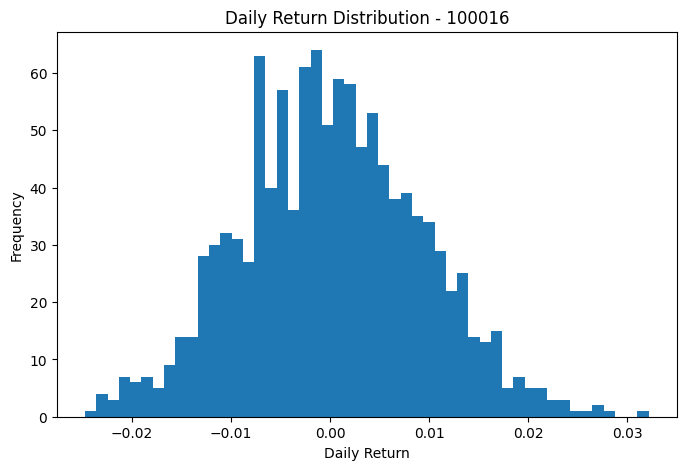

In [7]:
sample_fund = nav["amfi_code"].iloc[0]

sample_returns = nav[
    nav["amfi_code"] == sample_fund
]["daily_return"].dropna()

plt.figure(figsize=(8,5))
plt.hist(sample_returns, bins=50)

plt.title(f"Daily Return Distribution - {sample_fund}")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [8]:
print(nav["amfi_code"].nunique())

40


In [9]:
def calculate_cagr(start_nav, end_nav, years):
    return (end_nav / start_nav) ** (1 / years) - 1

In [10]:
cagr_results = []

for fund in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"] == fund].copy()
    df = df.sort_values("date")

    latest_nav = df.iloc[-1]["nav"]

    result = {
        "amfi_code": fund
    }

    for years in [1, 3, 5]:

        trading_days = years * 252

        if len(df) > trading_days:

            start_nav = df.iloc[-trading_days]["nav"]

            cagr = calculate_cagr(
                start_nav,
                latest_nav,
                years
            )

            result[f"{years}yr_cagr"] = cagr

        else:
            result[f"{years}yr_cagr"] = np.nan

    cagr_results.append(result)

cagr_table = pd.DataFrame(cagr_results)

cagr_table.head()

,amfi_code,1yr_cagr,3yr_cagr,5yr_cagr
0,100016,-0.033055,-0.000316,NaN
1,100025,0.025018,0.046143,NaN
2,100033,0.477346,0.336292,NaN
3,101206,0.450939,0.325286,NaN
4,101207,-0.242421,-0.026965,NaN


In [11]:
cagr_table.sort_values(
    "3yr_cagr",
    ascending=False
).head(10)

,amfi_code,1yr_cagr,3yr_cagr,5yr_cagr
16,119094,0.309182,0.360660,NaN
2,100033,0.477346,0.336292,NaN
3,101206,0.450939,0.325286,NaN
34,148567,0.145807,0.312786,NaN
25,120505,0.303534,0.302065,NaN
24,120504,0.115007,0.283698,NaN
21,119598,0.845322,0.278144,NaN
19,119551,0.488839,0.277274,NaN
8,102887,0.127279,0.256630,NaN
30,120843,0.284811,0.256619,NaN


In [12]:
cagr_table.to_csv(
    "../reports/cagr_comparison.csv",
    index=False
)

print("CAGR table saved.")

CAGR table saved.


In [13]:
cagr_table.head()

,amfi_code,1yr_cagr,3yr_cagr,5yr_cagr
0,100016,-0.033055,-0.000316,NaN
1,100025,0.025018,0.046143,NaN
2,100033,0.477346,0.336292,NaN
3,101206,0.450939,0.325286,NaN
4,101207,-0.242421,-0.026965,NaN


5-year CAGR could not be computed because the available NAV history does not span five years

In [14]:
rf = 0.065  # 6.5% annual risk-free rate

daily_rf = rf / 252

In [15]:
def sharpe_ratio(returns):

    returns = returns.dropna()

    excess_returns = returns - daily_rf

    sharpe = (
        excess_returns.mean()
        / returns.std()
    ) * np.sqrt(252)

    return sharpe

In [16]:
sharpe_results = []

for fund in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == fund
    ]["daily_return"]

    sharpe = sharpe_ratio(returns)

    sharpe_results.append({
        "amfi_code": fund,
        "sharpe_ratio": sharpe
    })

sharpe_df = pd.DataFrame(sharpe_results)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [17]:
sharpe_df = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
)

sharpe_df.head(10)

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101
38,149323,1.132122
2,100033,1.093699
9,118632,1.081659
3,101206,1.027213
24,120504,1.026524


In [18]:
sharpe_df.to_csv(
    "../reports/sharpe_ranking.csv",
    index=False
)

print("Sharpe ranking saved.")

Sharpe ranking saved.


In [19]:
print(sharpe_df["sharpe_ratio"].describe())

count    40.000000
mean      0.537220
std       0.573689
min      -0.815567
25%       0.064696
50%       0.647043
75%       1.005304
max       1.448291
Name: sharpe_ratio, dtype: float64


In [20]:
sharpe_df.head(10)

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101
38,149323,1.132122
2,100033,1.093699
9,118632,1.081659
3,101206,1.027213
24,120504,1.026524


In [21]:
def sortino_ratio(returns):

    returns = returns.dropna()

    excess_returns = returns - daily_rf

    downside_returns = returns[returns < 0]

    downside_std = downside_returns.std()

    if downside_std == 0:
        return np.nan

    sortino = (
        excess_returns.mean()
        / downside_std
    ) * np.sqrt(252)

    return sortino

In [22]:
sortino_results = []

for fund in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == fund
    ]["daily_return"]

    score = sortino_ratio(returns)

    sortino_results.append({
        "amfi_code": fund,
        "sortino_ratio": score
    })

sortino_df = pd.DataFrame(sortino_results)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [23]:
sortino_df = sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
)

sortino_df.head(10)

,amfi_code,sortino_ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353
38,149323,1.875101
9,118632,1.850133
2,100033,1.829134
24,120504,1.805294
3,101206,1.799563


In [24]:
sortino_df.to_csv(
    "../reports/sortino_ranking.csv",
    index=False
)

In [25]:
sortino_df["sortino_ratio"].describe()

count    40.000000
mean      0.923338
std       1.005410
min      -1.681038
25%       0.106664
50%       1.116936
75%       1.727739
max       2.385644
Name: sortino_ratio, dtype: float64

In [26]:
benchmark = pd.read_csv(
    "../Data/raw/10_benchmark_indices.csv"
)

print(benchmark.columns)
print(benchmark.head())

Index(['date', 'index_name', 'close_value'], dtype='str')
         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15


In [27]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [28]:
benchmark["index_name"].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [29]:
from scipy.stats import linregress

alpha_beta_results = []

In [30]:
for fund in nav["amfi_code"].unique():

    fund_returns = nav[
        nav["amfi_code"] == fund
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund_returns,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) < 30:
        continue

    slope, intercept, r_value, p_value, std_err = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha = intercept * 252
    beta = slope

    alpha_beta_results.append({
        "amfi_code": fund,
        "alpha": alpha,
        "beta": beta
    })

In [31]:
alpha_beta_df = pd.DataFrame(
    alpha_beta_results
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [32]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


In [33]:
alpha_beta_df.sort_values(
    "alpha",
    ascending=False
).head(10)

,amfi_code,alpha,beta
21,119598,0.303370,-0.023196
39,149324,0.300579,0.011455
25,120505,0.292636,0.000549
36,148569,0.282704,0.018134
30,120843,0.273305,-0.022830
2,100033,0.271954,0.005104
34,148567,0.269838,0.023684
38,149323,0.265986,-0.002523
16,119094,0.260767,-0.066265
19,119551,0.232010,-0.031751


In [34]:
def max_drawdown(nav_series):

    running_max = nav_series.cummax()

    drawdown = (
        nav_series /
        running_max
    ) - 1

    return drawdown.min()

In [35]:
mdd_results = []

for fund in nav["amfi_code"].unique():

    fund_nav = nav[
        nav["amfi_code"] == fund
    ]["nav"]

    mdd = max_drawdown(fund_nav)

    mdd_results.append({
        "amfi_code": fund,
        "max_drawdown": mdd
    })

mdd_df = pd.DataFrame(mdd_results)

mdd_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [36]:
alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [37]:
alpha_beta_df.sort_values(
    "alpha",
    ascending=False
).head()

,amfi_code,alpha,beta
21,119598,0.303370,-0.023196
39,149324,0.300579,0.011455
25,120505,0.292636,0.000549
36,148569,0.282704,0.018134
30,120843,0.273305,-0.022830


In [38]:
def max_drawdown(nav_series):

    running_max = nav_series.cummax()

    drawdown = (
        nav_series /
        running_max
    ) - 1

    return drawdown.min()

In [39]:
mdd_results = []

for fund in nav["amfi_code"].unique():

    fund_nav = nav[
        nav["amfi_code"] == fund
    ]["nav"]

    mdd = max_drawdown(fund_nav)

    mdd_results.append({
        "amfi_code": fund,
        "max_drawdown": mdd
    })

mdd_df = pd.DataFrame(mdd_results)

mdd_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [40]:
mdd_df.sort_values(
    "max_drawdown"
).head(10)

,amfi_code,max_drawdown
22,119599,-0.525742
17,119095,-0.516778
4,101207,-0.354469
39,149324,-0.311719
21,119598,-0.287060
7,102886,-0.280011
0,100016,-0.247344
29,120842,-0.240035
11,118634,-0.233449
15,119093,-0.217514


In [41]:
mdd_df.to_csv(
    "../reports/max_drawdown.csv",
    index=False
)

In [42]:
scorecard = (
    cagr_table
    .merge(sharpe_df, on="amfi_code")
    .merge(alpha_beta_df, on="amfi_code")
    .merge(mdd_df, on="amfi_code")
)

scorecard.head()

,amfi_code,1yr_cagr,3yr_cagr,5yr_cagr,sharpe_ratio,alpha,beta,max_drawdown
0,100016,-0.033055,-0.000316,NaN,-0.201517,0.037476,-0.058268,-0.247344
1,100025,0.025018,0.046143,NaN,-0.567095,0.042818,0.001158,-0.043083
2,100033,0.477346,0.336292,NaN,1.093699,0.271954,0.005104,-0.162172
3,101206,0.450939,0.325286,NaN,1.027213,0.213998,0.021086,-0.112916
4,101207,-0.242421,-0.026965,NaN,0.162661,0.108971,-0.065289,-0.354469


In [43]:
scorecard["return_rank"] = (
    scorecard["3yr_cagr"]
    .rank(pct=True)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(pct=True)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(pct=True)
)

scorecard["dd_rank"] = (
    (-scorecard["max_drawdown"])
    .rank(pct=True)
)

In [44]:
scorecard["fund_score"] = (

      scorecard["return_rank"] * 35

    + scorecard["sharpe_rank"] * 30

    + scorecard["alpha_rank"] * 20

    + scorecard["dd_rank"] * 15
)

In [45]:
scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

scorecard.head(10)

,amfi_code,1yr_cagr,3yr_cagr,5yr_cagr,sharpe_ratio,alpha,beta,max_drawdown,return_rank,sharpe_rank,alpha_rank,dd_rank,fund_score
25,120505,0.303534,0.302065,NaN,1.180101,0.292636,0.000549,-0.181885,0.900,0.900,0.950,0.625,86.875
2,100033,0.477346,0.336292,NaN,1.093699,0.271954,0.005104,-0.162172,0.975,0.850,0.875,0.500,84.625
16,119094,0.309182,0.360660,NaN,0.998231,0.260767,-0.066265,-0.209609,1.000,0.750,0.800,0.700,84.000
21,119598,0.845322,0.278144,NaN,0.945308,0.303370,-0.023196,-0.287060,0.850,0.675,1.000,0.900,83.500
34,148567,0.145807,0.312786,NaN,1.448291,0.269838,0.023684,-0.112657,0.925,1.000,0.850,0.200,82.375
39,149324,0.620818,0.250297,NaN,0.949796,0.300579,0.011455,-0.311719,0.750,0.700,0.975,0.925,80.625
36,148569,0.444657,0.233171,NaN,1.234930,0.282704,0.018134,-0.163967,0.700,0.950,0.925,0.525,79.375
30,120843,0.284811,0.256619,NaN,1.306744,0.273305,-0.022830,-0.129740,0.775,0.975,0.900,0.325,79.250
19,119551,0.488839,0.277274,NaN,1.208267,0.232010,-0.031751,-0.150124,0.825,0.925,0.775,0.425,78.500
38,149323,0.223056,0.242425,NaN,1.132122,0.265986,-0.002523,-0.172481,0.725,0.875,0.825,0.550,76.375


In [46]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved")

fund_scorecard.csv saved


In [47]:
benchmark["index_name"].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [48]:
top5_funds = (
    scorecard
    .sort_values("fund_score", ascending=False)
    .head(5)["amfi_code"]
    .tolist()
)

print(top5_funds)

[120505, 100033, 119094, 119598, 148567]


In [49]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty50 = nifty50.sort_values("date")
nifty100 = nifty100.sort_values("date")

In [50]:
nifty50["cum_return"] = (
    nifty50["close_value"] /
    nifty50["close_value"].iloc[0]
)

nifty100["cum_return"] = (
    nifty100["close_value"] /
    nifty100["close_value"].iloc[0]
)

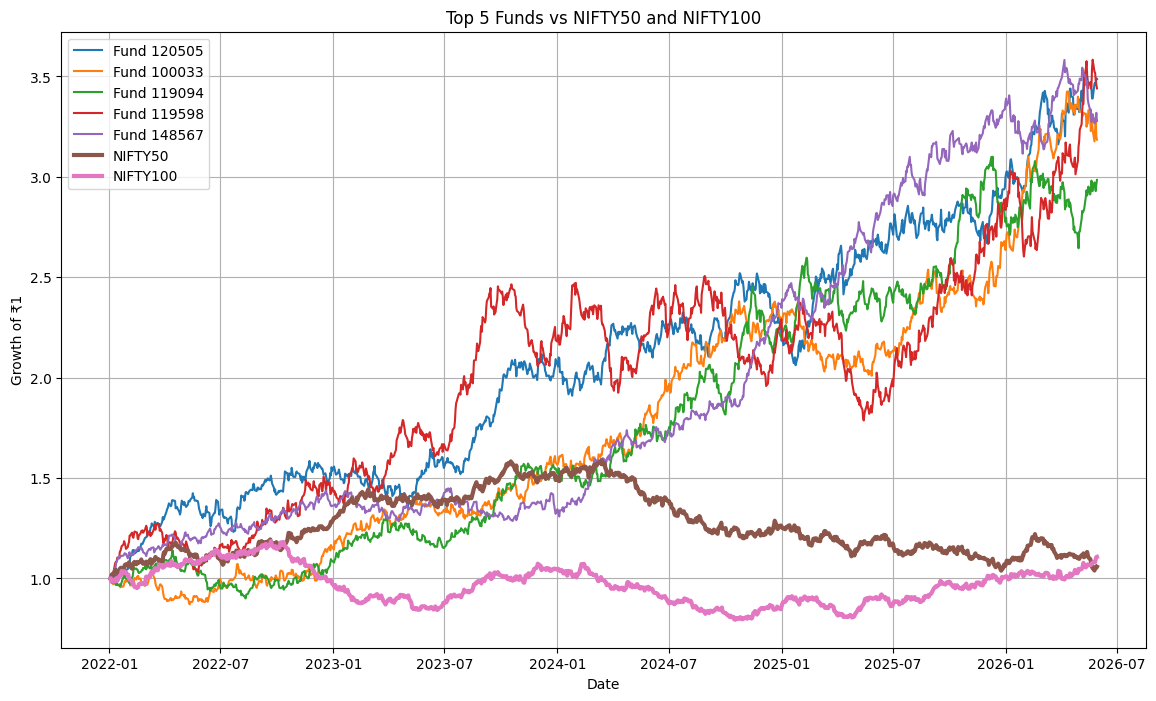

In [51]:
plt.figure(figsize=(14,8))

for fund in top5_funds:

    df = nav[
        nav["amfi_code"] == fund
    ].copy()

    df = df.sort_values("date")

    df["cum_return"] = (
        df["nav"] /
        df["nav"].iloc[0]
    )

    plt.plot(
        df["date"],
        df["cum_return"],
        label=f"Fund {fund}"
    )

plt.plot(
    nifty50["date"],
    nifty50["cum_return"],
    linewidth=3,
    label="NIFTY50"
)

plt.plot(
    nifty100["date"],
    nifty100["cum_return"],
    linewidth=3,
    label="NIFTY100"
)

plt.title("Top 5 Funds vs NIFTY50 and NIFTY100")
plt.xlabel("Date")
plt.ylabel("Growth of ₹1")
plt.legend()
plt.grid(True)

plt.savefig(
    "../reports/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [52]:
def tracking_error(
    fund_returns,
    benchmark_returns
):

    diff = fund_returns - benchmark_returns

    return diff.std() * np.sqrt(252)

In [53]:
tracking_results = []

for fund in top5_funds:

    fund_df = nav[
        nav["amfi_code"] == fund
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund_df,
        nifty100[["date", "benchmark_return"]],
        on="date"
    ).dropna()

    te = tracking_error(
        merged["daily_return"],
        merged["benchmark_return"]
    )

    tracking_results.append({
        "amfi_code": fund,
        "tracking_error": te
    })

tracking_df = pd.DataFrame(tracking_results)

tracking_df

KeyError: "['benchmark_return'] not in index"

In [54]:
print(nifty100.columns)

Index(['date', 'index_name', 'close_value', 'cum_return'], dtype='str')


In [55]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

print(nifty100.columns)
print(nifty100.head())

Index(['date', 'index_name', 'close_value', 'benchmark_return'], dtype='str')
           date index_name  close_value  benchmark_return
1150 2022-01-03   NIFTY100     17778.24               NaN
1151 2022-01-04   NIFTY100     17537.52         -0.013540
1152 2022-01-05   NIFTY100     17607.73          0.004003
1153 2022-01-06   NIFTY100     17556.05         -0.002935
1154 2022-01-07   NIFTY100     17664.02          0.006150


In [56]:
def tracking_error(fund_returns, benchmark_returns):

    diff = fund_returns - benchmark_returns

    return diff.std() * np.sqrt(252)


tracking_results = []

for fund in top5_funds:

    fund_df = nav[
        nav["amfi_code"] == fund
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund_df,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    te = tracking_error(
        merged["daily_return"],
        merged["benchmark_return"]
    )

    tracking_results.append({
        "amfi_code": fund,
        "tracking_error": te
    })

tracking_df = pd.DataFrame(tracking_results)

tracking_df

,amfi_code,tracking_error
0,120505,0.231968
1,100033,0.228699
2,119094,0.237652
3,119598,0.283881
4,148567,0.189664


In [57]:
print(nifty100.columns)
print(top5_funds)

Index(['date', 'index_name', 'close_value', 'benchmark_return'], dtype='str')
[120505, 100033, 119094, 119598, 148567]


In [58]:
tracking_results = []

for fund in top5_funds:

    fund_df = nav[
        nav["amfi_code"] == fund
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund_df,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    te = (
        (merged["daily_return"] - merged["benchmark_return"])
        .std()
        * np.sqrt(252)
    )

    tracking_results.append({
        "amfi_code": fund,
        "tracking_error": te
    })

tracking_df = pd.DataFrame(tracking_results)

tracking_df

,amfi_code,tracking_error
0,120505,0.231968
1,100033,0.228699
2,119094,0.237652
3,119598,0.283881
4,148567,0.189664


In [59]:
import os

print(os.listdir("../reports"))


['alpha_beta.csv', 'benchmark_comparison.png', 'cagr_comparison.csv', 'data_dictionary.md', 'fund_scorecard.csv', 'max_drawdown.csv', 'sharpe_ranking.csv', 'sortino_ranking.csv']
